In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

print("All imports successful!")

All imports successful!


In [2]:
train_df = pd.read_csv("data/kdd_train.csv")
test_df  = pd.read_csv("data/kdd_test.csv")

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nFirst 3 rows:")
train_df.head(3)

Train shape: (125973, 42)
Test shape:  (22544, 42)

First 3 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune


In [3]:
print(train_df.columns.tolist())

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'labels']


In [4]:
print(train_df["labels"].value_counts())

labels
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [5]:
train_df["labels"] = train_df["labels"].apply(lambda x: 0 if x == "normal" else 1)
test_df["labels"]  = test_df["labels"].apply(lambda x: 0 if x == "normal" else 1)

print(train_df["labels"].value_counts())


labels
0    67343
1    58630
Name: count, dtype: int64


In [6]:
cat_cols = ["protocol_type", "service", "flag"]

le = LabelEncoder()
for col in cat_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])

print("Done! Sample:")
print(train_df[cat_cols].head(3))

Done! Sample:
   protocol_type  service  flag
0              1       20     9
1              2       44     9
2              1       49     5


In [7]:
X_train = train_df.drop("labels", axis=1)
y_train = train_df["labels"]

X_test = test_df.drop("labels", axis=1)
y_test = test_df["labels"]

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (125973, 41)
X_test shape:  (22544, 41)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done!")
print("First 3 rows of scaled training data:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head(3))

Scaling done!
First 3 rows of scaled training data:
   duration  protocol_type   service      flag  src_bytes  dst_bytes  \
0 -0.110249      -0.124706 -0.686785  0.751111  -0.007679  -0.004919   
1 -0.110249       2.219312  0.781428  0.751111  -0.007737  -0.004919   
2 -0.110249      -0.124706  1.087305 -0.736235  -0.007762  -0.004919   

       land  wrong_fragment    urgent       hot  ...  dst_host_count  \
0 -0.014089       -0.089486 -0.007736 -0.095076  ...       -0.324063   
1 -0.014089       -0.089486 -0.007736 -0.095076  ...        0.734343   
2 -0.014089       -0.089486 -0.007736 -0.095076  ...        0.734343   

   dst_host_srv_count  dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0           -0.818890               -0.782367               -0.280282   
1           -1.035688               -1.161030                2.736852   
2           -0.809857               -0.938287               -0.174417   

   dst_host_same_src_port_rate  dst_host_srv_diff_host_rate  \
0             

In [9]:
pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print(f"Original features : {X_train.shape[1]}")
print(f"After PCA         : {X_train_pca.shape[1]}")
print(f"Variance retained : {np.cumsum(pca.explained_variance_ratio_)[-1]:.4f}")

Original features : 41
After PCA         : 20
Variance retained : 0.8978


In [10]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_pca, y_train)

print("Naive Bayes training done!")

Naive Bayes training done!


In [11]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_pca, y_train)

print("Logistic Regression training done!")

Logistic Regression training done!


In [12]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_model = CalibratedClassifierCV(LinearSVC(max_iter=1000, random_state=42))
svm_model.fit(X_train_pca, y_train)

print("SVM training done!")

SVM training done!


In [13]:
from sklearn.metrics import accuracy_score, f1_score

models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "SVM": svm_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    print(f"{name:25s} Accuracy: {acc:.4f}  F1 Score: {f1:.4f}")

Naive Bayes               Accuracy: 0.8801  F1 Score: 0.8791
Logistic Regression       Accuracy: 0.8895  F1 Score: 0.8817
SVM                       Accuracy: 0.8901  F1 Score: 0.8826


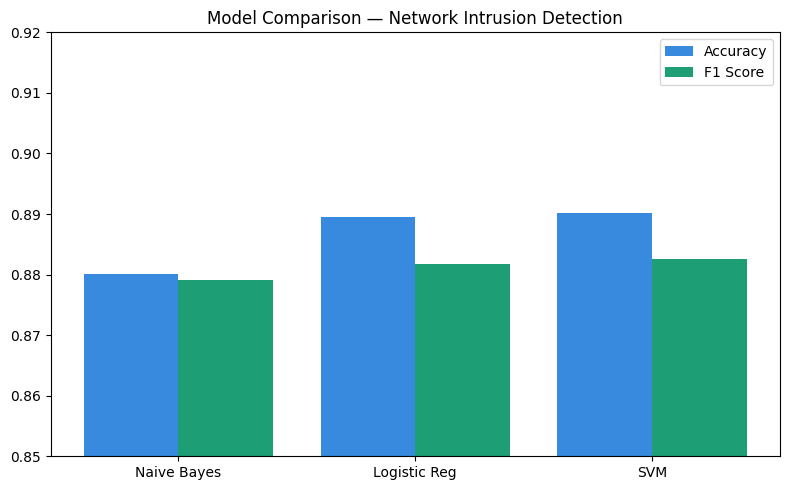

In [14]:
import matplotlib.pyplot as plt

names = ["Naive Bayes", "Logistic Reg", "SVM"]
accuracies = [0.8801, 0.8895, 0.8901]
f1_scores  = [0.8791, 0.8817, 0.8826]

x = range(len(names))
plt.figure(figsize=(8, 5))
plt.bar([i - 0.2 for i in x], accuracies, width=0.4, label="Accuracy", color="#378ADD")
plt.bar([i + 0.2 for i in x], f1_scores,  width=0.4, label="F1 Score",  color="#1D9E75")
plt.xticks(x, names)
plt.ylim(0.85, 0.92)
plt.title("Model Comparison — Network Intrusion Detection")
plt.legend()
plt.tight_layout()
plt.show()

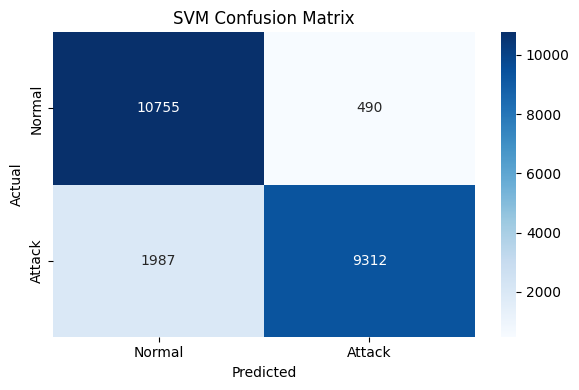

In [15]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_svm = svm_model.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Attack"],
            yticklabels=["Normal", "Attack"])
plt.title("SVM Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [16]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(nb_model,  "models/naive_bayes.pkl")
joblib.dump(lr_model,  "models/logistic_regression.pkl")
joblib.dump(svm_model, "models/svm.pkl")
joblib.dump(scaler,    "models/scaler.pkl")
joblib.dump(pca,       "models/pca.pkl")

print("All models saved to models/ folder!")

All models saved to models/ folder!


In [17]:
import os
print(os.getcwd())

C:\Users\priya\nids_project


In [18]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(nb_model,  "models/naive_bayes.pkl")
joblib.dump(lr_model,  "models/logistic_regression.pkl")
joblib.dump(svm_model, "models/svm.pkl")
joblib.dump(scaler,    "models/scaler.pkl")
joblib.dump(pca,       "models/pca.pkl")

print("All models saved!")

All models saved!


In [19]:
attack_map = {
    'normal': 'Normal',
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS',
    'ipsweep': 'Probe', 'nmap': 'Probe', 'portsweep': 'Probe', 'satan': 'Probe',
    'ftp_write': 'R2L', 'guess_passwd': 'R2L', 'imap': 'R2L', 'multihop': 'R2L',
    'phf': 'R2L', 'spy': 'R2L', 'warezclient': 'R2L', 'warezmaster': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'rootkit': 'U2R'
}

# Reload original data
train_df2 = pd.read_csv("data/kdd_train.csv")
test_df2  = pd.read_csv("data/kdd_test.csv")

train_df2["attack_type"] = train_df2["labels"].map(attack_map).fillna("Unknown")
test_df2["attack_type"]  = test_df2["labels"].map(attack_map).fillna("Unknown")

print(train_df2["attack_type"].value_counts())

attack_type
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [21]:
from sklearn.ensemble import RandomForestClassifier

# Encode categorical columns
cat_cols = ["protocol_type", "service", "flag"]
le = LabelEncoder()
for col in cat_cols:
    train_df2[col] = le.fit_transform(train_df2[col])
    test_df2[col]  = le.transform(test_df2[col])

# Replace Unknown with Normal
train_df2["attack_type"] = train_df2["attack_type"].replace("Unknown", "Normal")
test_df2["attack_type"]  = test_df2["attack_type"].replace("Unknown", "Normal")

# Encode attack type label
le_attack = LabelEncoder()
train_df2["attack_encoded"] = le_attack.fit_transform(train_df2["attack_type"])
test_df2["attack_encoded"]  = le_attack.transform(test_df2["attack_type"])

# Features
X_train2 = train_df2.drop(["labels", "attack_type", "attack_encoded"], axis=1)
y_train2  = train_df2["attack_encoded"]
X_test2   = test_df2.drop(["labels", "attack_type", "attack_encoded"], axis=1)
y_test2   = test_df2["attack_encoded"]

# Scale
X_train2_scaled = scaler.transform(X_train2)
X_test2_scaled  = scaler.transform(X_test2)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train2_scaled, y_train2)

print("Random Forest training done!")
print("Classes:", le_attack.classes_)

Random Forest training done!
Classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


In [23]:
joblib.dump(rf_model,  "models/random_forest.pkl")
joblib.dump(le_attack, "models/le_attack.pkl")

print("Saved!")

Saved!


In [28]:
# Reload fresh original data
train_original = pd.read_csv("data/kdd_train.csv")

le_protocol = LabelEncoder()
le_service  = LabelEncoder()
le_flag     = LabelEncoder()

le_protocol.fit(train_original["protocol_type"])
le_service.fit(train_original["service"])
le_flag.fit(train_original["flag"])

joblib.dump(le_protocol, "models/le_protocol.pkl")
joblib.dump(le_service,  "models/le_service.pkl")
joblib.dump(le_flag,     "models/le_flag.pkl")

print("Protocol classes:", le_protocol.classes_)
print("Flag classes:", le_flag.classes_)
print("Encoders saved correctly!")

Protocol classes: ['icmp' 'tcp' 'udp']
Flag classes: ['OTH' 'REJ' 'RSTO' 'RSTOS0' 'RSTR' 'S0' 'S1' 'S2' 'S3' 'SF' 'SH']
Encoders saved correctly!
